# Ridge and Lasso Regularization - QSAR Aquatic Toxicity Prediction

## 1. Project Overview

This project demonstrates **Ridge (L2) and Lasso (L1) regularization** using the QSAR Aquatic Toxicity dataset.

The objective is to predict **LC50**, a continuous aquatic-toxicity response, from eight molecular descriptors. Ordinary Linear Regression is included only as an **unregularized baseline**.

Unlike manually choosing a single regularization strength, this notebook uses **RidgeCV** and **LassoCV** to select `alpha` through cross-validation on the training data. The workflow focuses on feature scaling, regularization, predictive evaluation, coefficient shrinkage, and Lasso feature selection.


## 2. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## 3. Load the Clean Dataset

In [2]:
df = pd.read_csv("qsar_aquatic_toxicity_clean.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (546, 9)


,TPSA,SAacc,H050,MLOGP,RDCHI,GATS1p,nN,C040,LC50
0,0.00,0.0,0,2.419,1.225,0.667,0,0,3.740
1,0.00,0.0,0,2.638,1.401,0.632,0,0,4.330
2,9.23,11.0,0,5.799,2.930,0.486,0,0,7.019
3,9.23,11.0,0,5.453,2.887,0.495,0,0,6.723
4,9.23,11.0,0,4.068,2.758,0.695,0,0,5.979


## 4. Dataset Structure

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nStatistical summary:")
display(df.describe().T)

Rows: 546
Columns: 9

Column names:
['TPSA', 'SAacc', 'H050', 'MLOGP', 'RDCHI', 'GATS1p', 'nN', 'C040', 'LC50']

Data types:
TPSA      float64
SAacc     float64
H050        int64
MLOGP     float64
RDCHI     float64
GATS1p    float64
nN          int64
C040        int64
LC50      float64
dtype: object

Statistical summary:


,count,mean,std,min,25%,50%,75%,max
TPSA,546.0,48.472930,46.763983,0.000,15.7900,40.4600,70.02250,347.320
SAacc,546.0,58.869018,68.166554,0.000,11.0000,42.6830,77.49275,571.952
H050,546.0,0.937729,1.618632,0.000,0.0000,0.0000,1.00000,18.000
MLOGP,546.0,2.313493,1.741797,-6.446,1.2325,2.2735,3.39275,9.148
RDCHI,546.0,2.492299,0.811004,1.000,1.9750,2.3440,2.91100,6.439
GATS1p,546.0,1.046264,0.403677,0.281,0.7370,1.0205,1.26650,2.500
nN,546.0,1.003663,1.397240,0.000,0.0000,1.0000,2.00000,11.000
C040,546.0,0.353480,0.806827,0.000,0.0000,0.0000,0.00000,11.000
LC50,546.0,4.658421,1.665215,0.122,3.6015,4.5160,5.60750,10.047


## 5. Data Quality Checks

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values:
TPSA      0
SAacc     0
H050      0
MLOGP     0
RDCHI     0
GATS1p    0
nN        0
C040      0
LC50      0
dtype: int64

Total missing values: 0
Duplicate rows: 0


## 6. Data Preparation

The cleaned dataset contains **546 observations**, **8 molecular descriptor features**, and the continuous target **`LC50`**.

All variables are numerical. Exact duplicate rows are removed if present. No categorical encoding is required.


In [5]:
df = df.drop_duplicates().copy()

print("Prepared dataset shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

Prepared dataset shape: (546, 9)
Remaining missing values: 0


## 7. Exploratory Data Analysis

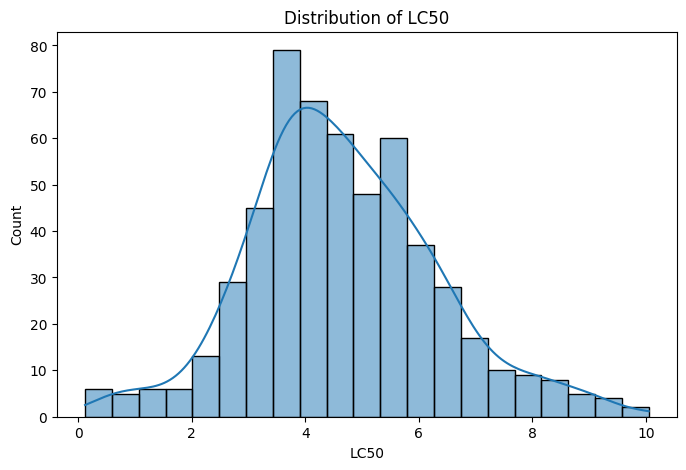

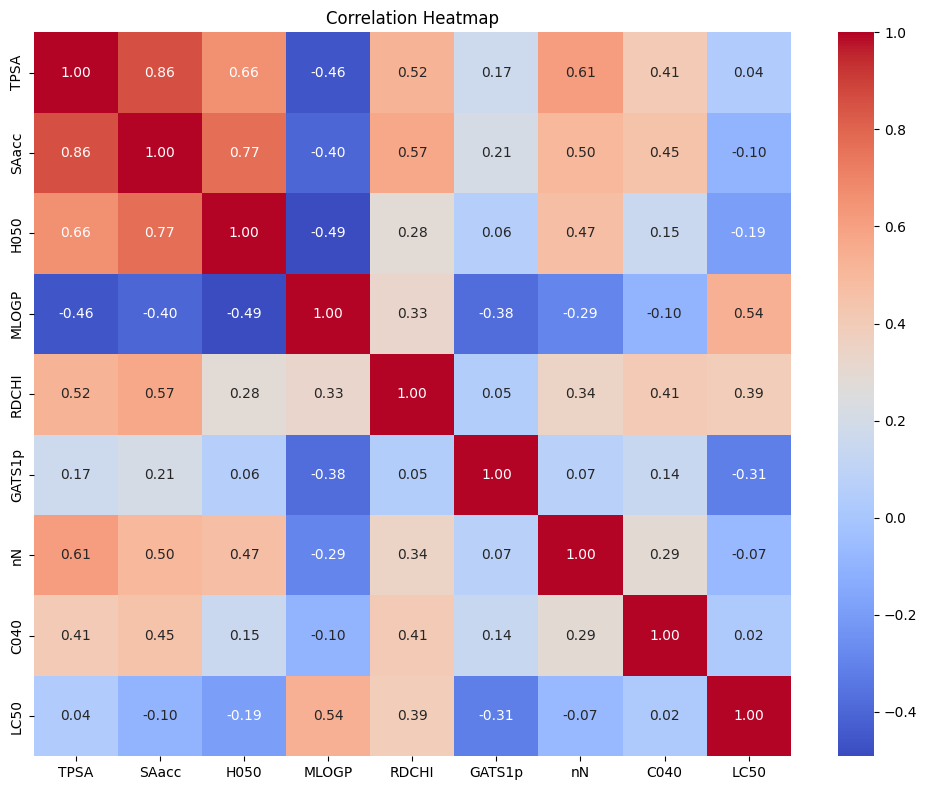

Feature correlations with LC50:


,Correlation
MLOGP,0.535512
RDCHI,0.390621
GATS1p,-0.311821
H050,-0.189121
SAacc,-0.097967
nN,-0.070179
TPSA,0.037984
C040,0.024310


In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df["LC50"], kde=True)
plt.title("Distribution of LC50")
plt.xlabel("LC50")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

target_corr = (
    df.corr()["LC50"]
    .drop("LC50")
    .sort_values(key=abs, ascending=False)
)

print("Feature correlations with LC50:")
display(target_corr.to_frame("Correlation"))

## 8. Prepare Features and Target

In [7]:
X = df.drop(columns=["LC50"])
y = df["LC50"]

print("Number of features:", X.shape[1])
print("Target:", y.name)
print("Features:", X.columns.tolist())

Number of features: 8
Target: LC50
Features: ['TPSA', 'SAacc', 'H050', 'MLOGP', 'RDCHI', 'GATS1p', 'nN', 'C040']


## 9. Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 436
Testing samples : 110


## 10. Feature Scaling

Ridge and Lasso regularization penalize coefficient magnitudes. Standardization places all predictors on comparable scales so the regularization penalty is applied fairly.

The scaler is fitted only on the training data and then applied to the test data to prevent data leakage.


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")

Feature scaling complete.


## 11. Unregularized Linear Baseline

Ordinary Linear Regression provides a reference point with no coefficient penalty. The Ridge and Lasso regularized models will be compared against this baseline.


In [10]:
baseline = LinearRegression()
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)

print("Linear baseline trained.")

Linear baseline trained.


## 12. Ridge and Lasso Regularization with Cross-Validated Alpha Selection

`RidgeCV` and `LassoCV` select the regularization strength from the training data using cross-validation.

- **Ridge (L2)** shrinks coefficients toward zero.
- **Lasso (L1)** can shrink some coefficients exactly to zero, providing implicit feature selection.


In [11]:
alphas = np.logspace(-4, 3, 100)

ridge = RidgeCV(alphas=alphas, cv=5)
lasso = LassoCV(alphas=alphas, cv=5, max_iter=100000, random_state=42)

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)
lasso_pred = lasso.predict(X_test_scaled)

print(f"Best Ridge alpha: {ridge.alpha_:.6f}")
print(f"Best Lasso alpha: {lasso.alpha_:.6f}")

Best Ridge alpha: 5.462277
Best Lasso alpha: 0.018307


## 13. Regularization Performance Evaluation

In [12]:
def evaluate(approach, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "Approach": approach,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R² Score": r2_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate("Linear Baseline", y_test, baseline_pred),
    evaluate("Ridge (L2 Regularization)", y_test, ridge_pred),
    evaluate("Lasso (L1 Regularization)", y_test, lasso_pred)
])

display(results.round(4))

,Approach,MAE,MSE,RMSE,R² Score
0,Linear Baseline,0.9084,1.4615,1.2089,0.4743
1,Ridge (L2 Regularization),0.9103,1.4563,1.2068,0.4761
2,Lasso (L1 Regularization),0.9085,1.4495,1.2040,0.4786


## 14. Compare R² Scores

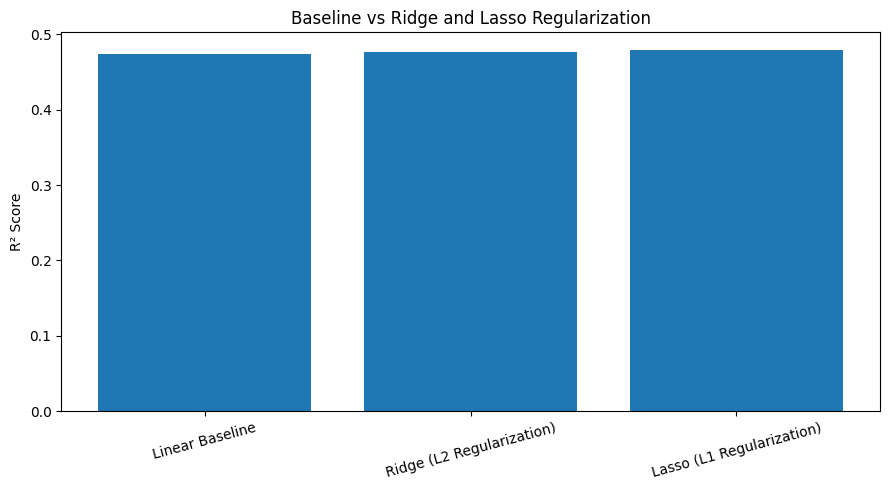

In [13]:
plt.figure(figsize=(9, 5))
plt.bar(results["Approach"], results["R² Score"])
plt.ylabel("R² Score")
plt.title("Baseline vs Ridge and Lasso Regularization")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 15. Actual vs Predicted Values

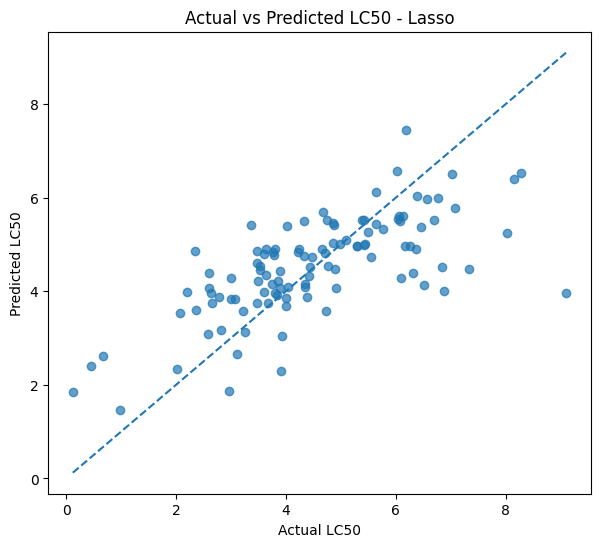

In [14]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, lasso_pred, alpha=0.7)

minimum = min(y_test.min(), lasso_pred.min())
maximum = max(y_test.max(), lasso_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")

plt.xlabel("Actual LC50")
plt.ylabel("Predicted LC50")
plt.title("Actual vs Predicted LC50 - Lasso")
plt.show()

## 16. Coefficient Shrinkage Analysis

The coefficients below are based on standardized features, allowing direct comparison of how Ridge and Lasso alter coefficient magnitudes relative to the unregularized baseline.


In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Linear Baseline": baseline.coef_,
    "Ridge (L2)": ridge.coef_,
    "Lasso (L1)": lasso.coef_
})

display(coefficients.round(4))

zero_count = int(np.sum(lasso.coef_ == 0))
print("Coefficients set exactly to zero by Lasso:", zero_count)

,Feature,Linear Baseline,Ridge (L2),Lasso (L1)
0,TPSA,1.3634,1.2091,1.1573
1,SAacc,-1.1351,-0.9697,-0.8584
2,H050,0.1183,0.0490,0.0000
3,MLOGP,0.7921,0.7397,0.7544
4,RDCHI,0.3768,0.3939,0.3525
5,GATS1p,-0.2765,-0.2944,-0.2799
6,nN,-0.3130,-0.2783,-0.2369
7,C040,0.0670,0.0468,0.0127


Coefficients set exactly to zero by Lasso: 1


## 17. Visualize Coefficient Shrinkage

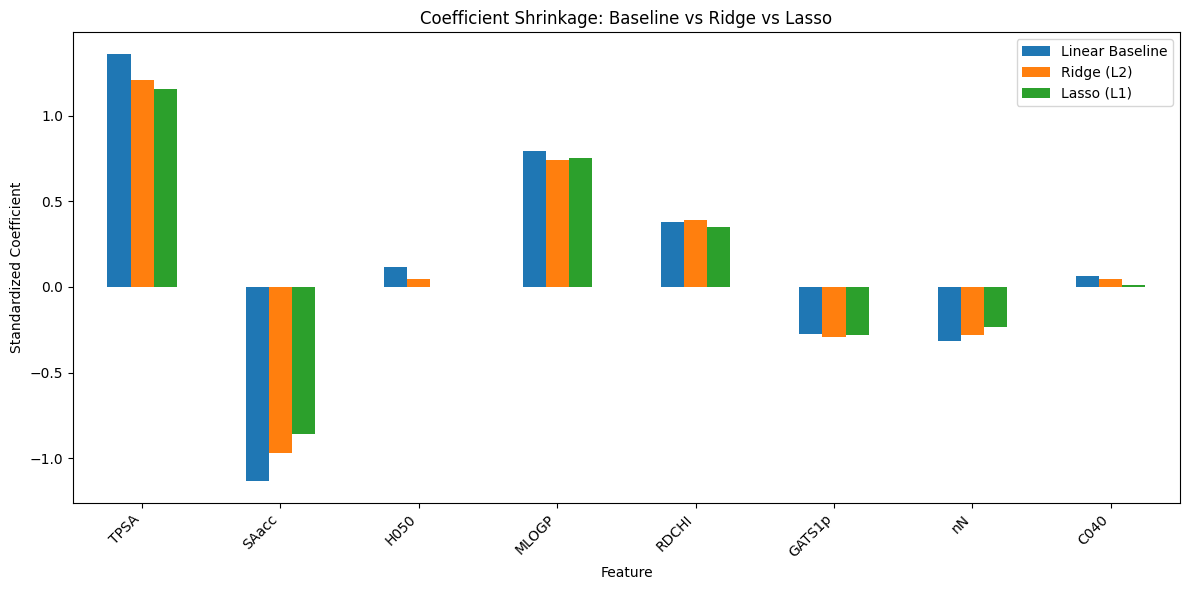

In [16]:
coefficients.set_index("Feature").plot(kind="bar", figsize=(12, 6))
plt.ylabel("Standardized Coefficient")
plt.title("Coefficient Shrinkage: Baseline vs Ridge vs Lasso")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 18. Selected Regularization Strengths

In [17]:
alpha_summary = pd.DataFrame({
    "Method": ["Ridge (L2)", "Lasso (L1)"],
    "Selected Alpha": [ridge.alpha_, lasso.alpha_]
})

display(alpha_summary)

,Method,Selected Alpha
0,Ridge (L2),5.462277
1,Lasso (L1),0.018307


## 19. Key Findings

- The unregularized Linear Regression baseline achieved an **R² score of 0.4743**.
- Ridge (L2) regularization slightly improved the R² score to **0.4761** and reduced MSE and RMSE compared with the baseline.
- Lasso (L1) regularization achieved the highest **R² score of 0.4786**, making it the best-performing approach based on R².
- Lasso also achieved the lowest **MSE of 1.4495** and **RMSE of 1.2040** among the three approaches.
- The Linear Regression baseline achieved a marginally lower **MAE of 0.9084**, compared with **0.9085** for Lasso. This difference is negligible.
- The relatively small differences between the three approaches indicate that regularization provided only a modest improvement in predictive performance on the held-out test set.
- RidgeCV and LassoCV used **5-fold cross-validation** on the training data to select appropriate regularization strengths rather than relying on manually chosen alpha values.
- The results demonstrate that regularization does not necessarily produce a large increase in R². Its primary purpose is to control model complexity and coefficient magnitude, while Lasso can additionally perform implicit feature selection by setting selected coefficients to zero.

## 20. Conclusion

This project demonstrated **Ridge and Lasso regularization** for predicting aquatic toxicity using numerical molecular descriptors from the QSAR Aquatic Toxicity dataset. Ordinary Linear Regression was included as an unregularized baseline for comparison.

Among the evaluated approaches, **Lasso (L1) regularization produced the best overall test-set performance**, achieving an R² score of **0.4786** and the lowest MSE and RMSE. Ridge (L2) regularization also produced a small improvement in R² and error metrics compared with the unregularized baseline.

However, the differences between the three approaches were relatively modest. This indicates that regularization did not substantially improve the predictive capability of the underlying linear model for this dataset.

The project nevertheless demonstrates the central purpose of regularization: controlling model complexity and coefficient magnitude rather than guaranteeing a large increase in predictive accuracy. Ridge provides L2-based coefficient shrinkage, while Lasso provides L1-based shrinkage with the additional ability to eliminate less influential predictors. Using RidgeCV and LassoCV with cross-validation also provides a more systematic approach to selecting regularization strength instead of relying on arbitrary alpha values.